In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("covid_19_data.csv")

In [3]:
df.head()

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0


In [4]:
df.tail()

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
306424,306425,05/29/2021,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55,102641.0,2335.0,95289.0
306425,306426,05/29/2021,Zeeland,Netherlands,2021-05-30 04:20:55,29147.0,245.0,0.0
306426,306427,05/29/2021,Zhejiang,Mainland China,2021-05-30 04:20:55,1364.0,1.0,1324.0
306427,306428,05/29/2021,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55,87550.0,1738.0,83790.0
306428,306429,05/29/2021,Zuid-Holland,Netherlands,2021-05-30 04:20:55,391559.0,4252.0,0.0


In [5]:
df.shape

(306429, 8)

In [6]:
df.info

<bound method DataFrame.info of            SNo ObservationDate     Province/State  Country/Region  \
0            1      01/22/2020              Anhui  Mainland China   
1            2      01/22/2020            Beijing  Mainland China   
2            3      01/22/2020          Chongqing  Mainland China   
3            4      01/22/2020             Fujian  Mainland China   
4            5      01/22/2020              Gansu  Mainland China   
...        ...             ...                ...             ...   
306424  306425      05/29/2021  Zaporizhia Oblast         Ukraine   
306425  306426      05/29/2021            Zeeland     Netherlands   
306426  306427      05/29/2021           Zhejiang  Mainland China   
306427  306428      05/29/2021    Zhytomyr Oblast         Ukraine   
306428  306429      05/29/2021       Zuid-Holland     Netherlands   

                Last Update  Confirmed  Deaths  Recovered  
0           1/22/2020 17:00        1.0     0.0        0.0  
1           1/22/20

In [8]:
df.columns

Index(['SNo', 'ObservationDate', 'Province/State', 'Country/Region',
       'Last Update', 'Confirmed', 'Deaths', 'Recovered'],
      dtype='object')

In [9]:
df.dtypes

SNo                  int64
ObservationDate     object
Province/State      object
Country/Region      object
Last Update         object
Confirmed          float64
Deaths             float64
Recovered          float64
dtype: object

In [10]:
df.describe()

,SNo,Confirmed,Deaths,Recovered
count,306429.000000,3.064290e+05,306429.000000,3.064290e+05
mean,153215.000000,8.567091e+04,2036.403268,5.042029e+04
std,88458.577156,2.775516e+05,6410.938048,2.015124e+05
min,1.000000,-3.028440e+05,-178.000000,-8.544050e+05
25%,76608.000000,1.042000e+03,13.000000,1.100000e+01
50%,153215.000000,1.037500e+04,192.000000,1.751000e+03
75%,229822.000000,5.075200e+04,1322.000000,2.027000e+04
max,306429.000000,5.863138e+06,112385.000000,6.399531e+06


In [11]:
df.isnull().sum()

SNo                    0
ObservationDate        0
Province/State     78103
Country/Region         0
Last Update            0
Confirmed              0
Deaths                 0
Recovered              0
dtype: int64

In [17]:
total_confirmed = df['Confirmed'].sum()
total_deaths = df['Deaths'].sum()
total_recovered = df['Recovered'].sum()

print("Total Confirmed:", total_confirmed)
print("Total Deaths:", total_deaths)
print("Total Recovered:", total_recovered)

Total Confirmed: 26252051758.0
Total Deaths: 624013017.0
Total Recovered: 15450237912.0


In [18]:
country_cases = df.groupby('Country/Region')[['Confirmed','Deaths','Recovered']].sum()

country_cases = country_cases.sort_values(by='Confirmed', ascending=False)

country_cases.head(10)

,Confirmed,Deaths,Recovered
Country/Region,,,
US,6.049146e+09,123303762.0,5.033710e+08
India,3.226768e+09,44424723.0,2.900590e+09
Brazil,2.653588e+09,72624610.0,2.313677e+09
Russia,9.305488e+08,18363719.0,7.907057e+08
France,8.551890e+08,22720818.0,6.940743e+07
UK,7.837944e+08,29171984.0,2.327572e+06
Spain,6.491118e+08,19065104.0,6.119362e+07
Italy,6.366943e+08,26000702.0,4.877998e+08
Turkey,6.189410e+08,6841158.0,5.641706e+08


In [21]:
df['ObservationDate'] = pd.to_datetime(df['ObservationDate'])

df = df.drop(columns=['SNo','Last Update'])

KeyError: "['SNo', 'Last Update'] not found in axis"

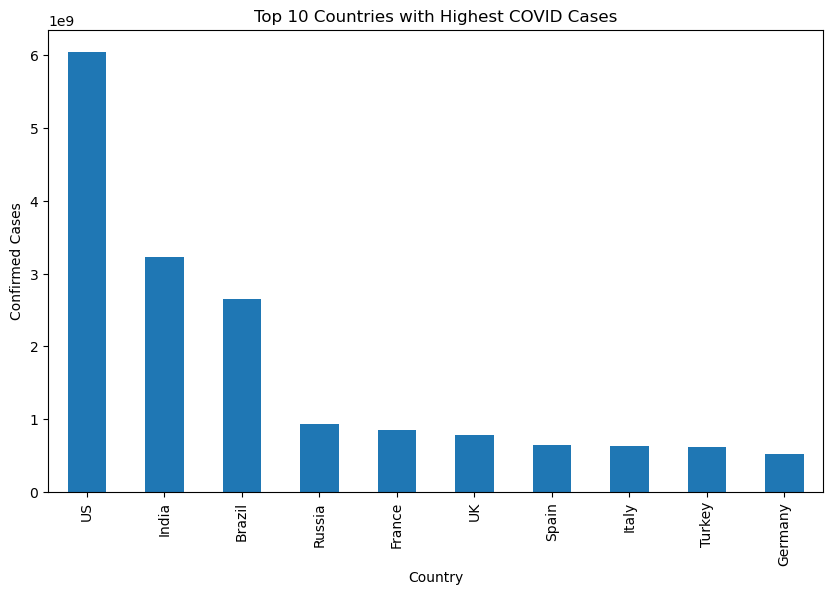

In [19]:
top10 = country_cases.head(10)

top10['Confirmed'].plot(kind='bar', figsize=(10,6))

plt.title("Top 10 Countries with Highest COVID Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.show()

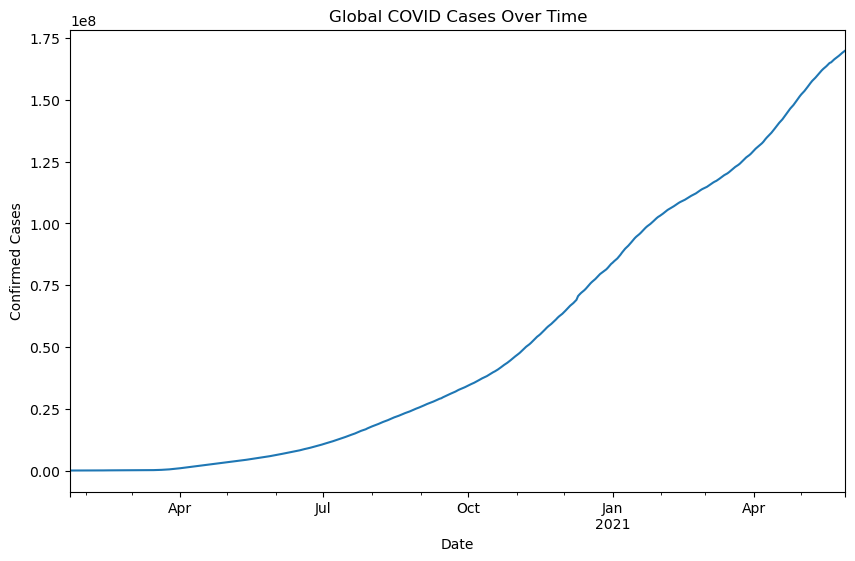

In [20]:
date_cases = df.groupby('ObservationDate')['Confirmed'].sum()

date_cases.plot(figsize=(10,6))

plt.title("Global COVID Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")

plt.show()